In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Image size — we resize all X-rays to 64x64 to keep it fast
IMG_SIZE = 64

def load_images_from_folder(folder_path):
    images = []
    labels = []
    
    for label in ['NORMAL', 'PNEUMONIA']:
        class_folder = os.path.join(folder_path, label)
        
        for filename in os.listdir(class_folder):
            if filename.endswith('.jpeg') or filename.endswith('.jpg') or filename.endswith('.png'):
                img_path = os.path.join(class_folder, filename)
                
                # Open image, convert to grayscale, resize
                img = Image.open(img_path).convert('L')
                img = img.resize((IMG_SIZE, IMG_SIZE))
                
                # Convert to numpy array and normalize (0-255 → 0-1)
                img_array = np.array(img) / 255.0
                
                # Flatten to 1D (64x64 = 4096 features per image)
                images.append(img_array.flatten())
                labels.append(label)
    
    return np.array(images), np.array(labels)

print("Loading training data... (this may take 1-2 minutes)")
X_train, y_train = load_images_from_folder(r'C:\Users\NASEEYA BEGUM\OneDrive\Desktop\pneumonia_classifier\data\train')

print("Loading test data...")
X_test, y_test = load_images_from_folder(r'C:\Users\NASEEYA BEGUM\OneDrive\Desktop\pneumonia_classifier\data\test')

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Features per image: {X_train.shape[1]}")

Loading training data... (this may take 1-2 minutes)
Loading test data...

Training samples: 5216
Test samples:     624
Features per image: 4096


Training class distribution:
  NORMAL: 1341 images
  PNEUMONIA: 3875 images


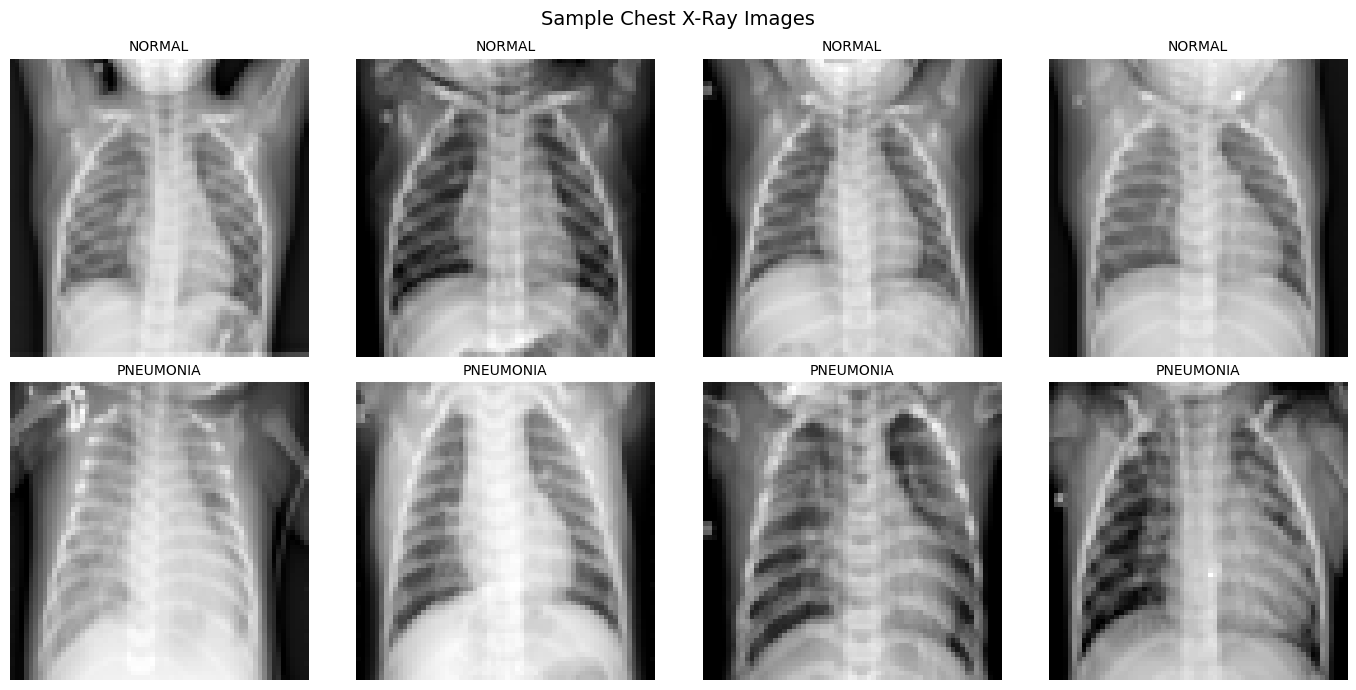

Saved to outputs/sample_xrays.png


In [9]:
# Count images per class
unique, counts = np.unique(y_train, return_counts=True)
print("Training class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"  {cls}: {cnt} images")

# Plot a few sample X-rays
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Chest X-Ray Images', fontsize=14)

for i, label in enumerate(['NORMAL', 'PNEUMONIA']):
    class_folder = rf'C:\Users\NASEEYA BEGUM\OneDrive\Desktop\pneumonia_classifier\data\train\{label}'
    files = os.listdir(class_folder)[:4]
    
    for j, fname in enumerate(files):
        img = Image.open(os.path.join(class_folder, fname)).convert('L').resize((IMG_SIZE, IMG_SIZE))
        axes[i][j].imshow(np.array(img), cmap='gray')
        axes[i][j].set_title(label, fontsize=10)
        axes[i][j].axis('off')

plt.tight_layout()
plt.savefig(r'C:\Users\NASEEYA BEGUM\OneDrive\Desktop\pneumonia_classifier\outputs\sample_xrays.png', dpi=150)
plt.show()
print("Saved to outputs/sample_xrays.png")

In [10]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

# Encode labels — NORMAL=0, PNEUMONIA=1
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Labels encoded: NORMAL=0, PNEUMONIA=1")
print(f"Training set: {len(y_train_enc)} samples")
print(f"Test set:     {len(y_test_enc)} samples\n")

# --- Model 1: SVM ---
print("Training SVM... (may take 2-4 minutes)")
start = time.time()
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train_enc)
svm_time = time.time() - start

svm_preds = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test_enc, svm_preds)
print(f"SVM done in {svm_time:.1f}s — Accuracy: {svm_acc*100:.2f}%\n")

# --- Model 2: Random Forest ---
print("Training Random Forest... (may take 1-2 minutes)")
start = time.time()
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train_enc)
rf_time = time.time() - start

rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test_enc, rf_preds)
print(f"Random Forest done in {rf_time:.1f}s — Accuracy: {rf_acc*100:.2f}%\n")

# --- Compare ---
print("=" * 40)
print(f"  SVM Accuracy:           {svm_acc*100:.2f}%")
print(f"  Random Forest Accuracy: {rf_acc*100:.2f}%")
print("=" * 40)
best_model = "SVM" if svm_acc > rf_acc else "Random Forest"
best_preds = svm_preds if svm_acc > rf_acc else rf_preds
print(f"\n  Best model: {best_model} ✓")

Labels encoded: NORMAL=0, PNEUMONIA=1
Training set: 5216 samples
Test set:     624 samples

Training SVM... (may take 2-4 minutes)
SVM done in 77.1s — Accuracy: 80.45%

Training Random Forest... (may take 1-2 minutes)
Random Forest done in 19.0s — Accuracy: 76.76%

  SVM Accuracy:           80.45%
  Random Forest Accuracy: 76.76%

  Best model: SVM ✓


In [15]:
!pip install xgboost

In [16]:
from xgboost import XGBClassifier

print("Training XGBoost... (may take 2-3 minutes)")
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=3,   # handles imbalance (3875/1341 ≈ 3)
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train_enc)
xgb_time = time.time() - start

xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test_enc, xgb_preds)
print(f"XGBoost done in {xgb_time:.1f}s — Accuracy: {xgb_acc*100:.2f}%\n")

# --- Updated comparison of all 3 models ---
print("=" * 45)
print(f"  SVM Accuracy:           {svm_acc*100:.2f}%")
print(f"  Random Forest Accuracy: {rf_acc*100:.2f}%")
print(f"  XGBoost Accuracy:       {xgb_acc*100:.2f}%")
print("=" * 45)

accs = {'SVM': svm_acc, 'Random Forest': rf_acc, 'XGBoost': xgb_acc}
best_name = max(accs, key=accs.get)
print(f"\n  Best model: {best_name} ✓")

Training XGBoost... (may take 2-3 minutes)
XGBoost done in 33.2s — Accuracy: 71.79%

  SVM Accuracy:           80.45%
  Random Forest Accuracy: 76.76%
  XGBoost Accuracy:       71.79%

  Best model: SVM ✓


CLASSIFICATION REPORT (SVM - Best Model)
              precision    recall  f1-score   support

      NORMAL       0.93      0.52      0.66       234
   PNEUMONIA       0.77      0.98      0.86       390

    accuracy                           0.80       624
   macro avg       0.85      0.75      0.76       624
weighted avg       0.83      0.80      0.79       624



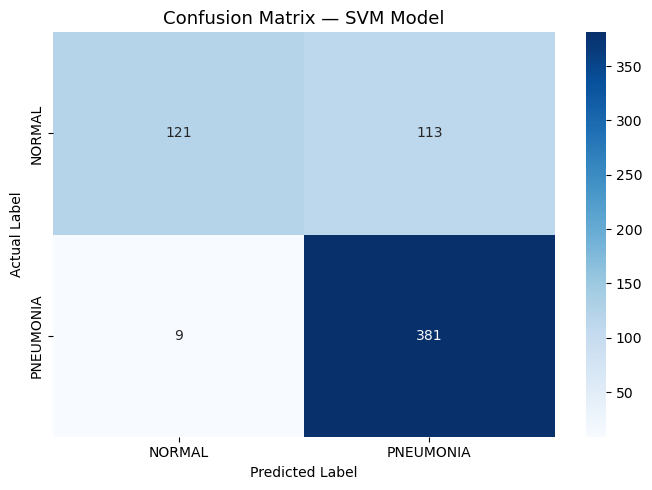

Saved: confusion_matrix.png


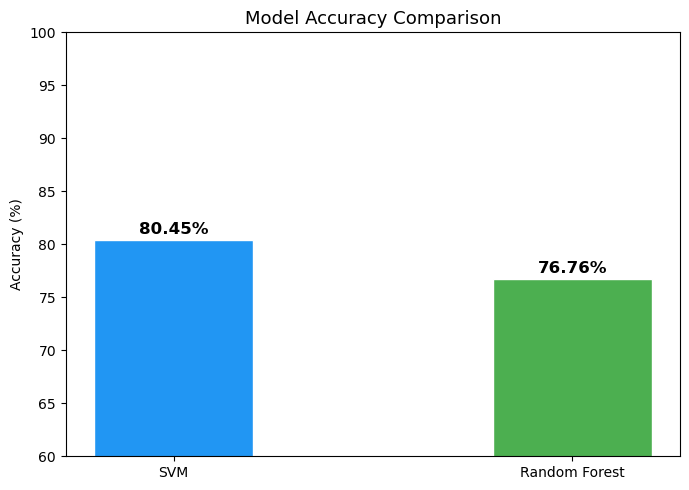

Saved: model_comparison.png

Testing on 8 unseen images from test set...


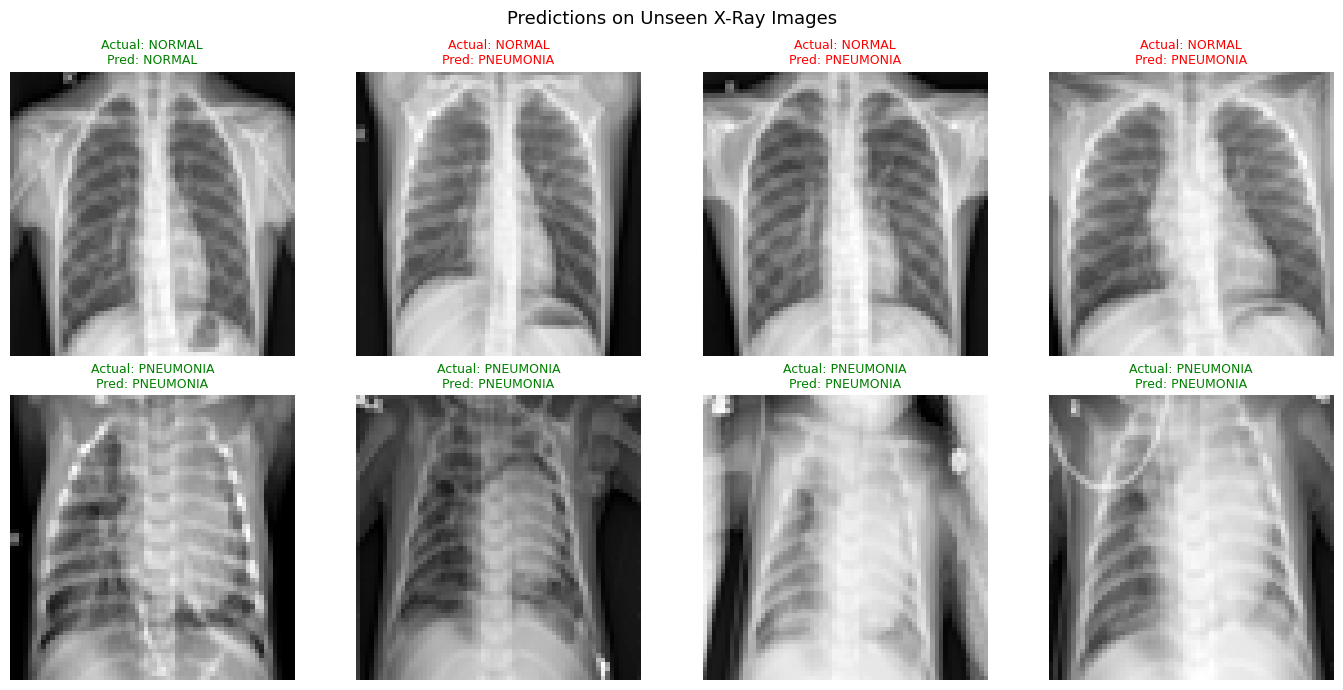

Saved: predictions.png


In [17]:
# ---- Detailed Classification Report ----
print("CLASSIFICATION REPORT (SVM - Best Model)")
print("=" * 50)
print(classification_report(y_test_enc, best_preds, target_names=['NORMAL', 'PNEUMONIA']))

# ---- Figure 1: Confusion Matrix ----
cm = confusion_matrix(y_test_enc, best_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title('Confusion Matrix — SVM Model', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(r'C:\Users\NASEEYA BEGUM\OneDrive\Desktop\pneumonia_classifier\outputs\confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

# ---- Figure 2: Model Accuracy Comparison ----
models = ['SVM', 'Random Forest']
accuracies = [svm_acc * 100, rf_acc * 100]
colors = ['#2196F3', '#4CAF50']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.4, edgecolor='white')
plt.ylim(60, 100)
plt.title('Model Accuracy Comparison', fontsize=13)
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\NASEEYA BEGUM\OneDrive\Desktop\pneumonia_classifier\outputs\model_comparison.png', dpi=150)
plt.show()
print("Saved: model_comparison.png")

# ---- Figure 3: Test on unseen images ----
print("\nTesting on 8 unseen images from test set...")
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Predictions on Unseen X-Ray Images', fontsize=13)

test_classes = ['NORMAL', 'PNEUMONIA']
idx = 0
for i, label in enumerate(test_classes):
    class_folder = rf'C:\Users\NASEEYA BEGUM\OneDrive\Desktop\pneumonia_classifier\data\test\{label}'
    files = os.listdir(class_folder)[:4]
    
    for j, fname in enumerate(files):
        img_path = os.path.join(class_folder, fname)
        img = Image.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img) / 255.0
        feature = img_array.flatten().reshape(1, -1)
        
        prediction = le.inverse_transform(svm_model.predict(feature))[0]
        actual = label
        
        color = 'green' if prediction == actual else 'red'
        axes[i][j].imshow(np.array(img), cmap='gray')
        axes[i][j].set_title(f'Actual: {actual}\nPred: {prediction}',
                              fontsize=9, color=color)
        axes[i][j].axis('off')

plt.tight_layout()
plt.savefig(r'C:\Users\NASEEYA BEGUM\OneDrive\Desktop\pneumonia_classifier\outputs\predictions.png', dpi=150)
plt.show()
print("Saved: predictions.png")

In [18]:
!pip install gradio

  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
    --------------------------------------- 1.0/42.9 MB 6.8 MB/s eta 0:00:07
   - -------------------------------------- 1.8/42.9 MB 5.3 MB/s eta 0:00:08
   -- ------------------------------------- 2.4/42.9 MB 3.7 MB/s eta 0:00:11
   -- ------------------------------------- 2.6/42.9 MB 3.3 MB/s eta 0:00:13
   -- ------------------------------------- 3.1/42.9 MB 2.8 MB/s eta 0:00:15
   --- ------------------------------------ 3.4/42.9 MB 2.7 MB/s eta 0:00:15
   --- ------------------------------------ 3.9/42.9 MB 2.6 MB/s eta 0:00:16
   ---- ----------------------------------- 4.5/42.9 MB 2.6 MB/s eta 0:00:15
   ---- ----------------------------------- 5.0/42.9 MB 2.6 MB/s eta 0:00:15
   ----- ---------------------------------- 5.5/42.9 MB 2.6 MB/s eta 0:00:15
   ----- ---------------------------------- 5.8/42.9 MB 2.6 MB/s eta 0:00:15
   ----- ------------

In [19]:
import gradio as gr
import numpy as np
from PIL import Image

def predict_xray(image):
    # Preprocess the uploaded image same way as training
    img = Image.fromarray(image).convert('L')
    img = img.resize((64, 64))
    img_array = np.array(img) / 255.0
    features = img_array.flatten().reshape(1, -1)
    
    # Get prediction
    prediction_enc = svm_model.predict(features)[0]
    prediction = le.inverse_transform([prediction_enc])[0]
    
    # Get confidence using decision function
    decision = svm_model.decision_function(features)[0]
    confidence = round(abs(decision) / (abs(decision) + 1) * 100, 2)
    
    # Format output
    if prediction == 'PNEUMONIA':
        result = f"🔴 PNEUMONIA DETECTED\nConfidence: {confidence}%\n\nPlease consult a doctor immediately."
    else:
        result = f"🟢 NORMAL\nConfidence: {confidence}%\n\nNo signs of pneumonia detected."
    
    return result

# Launch the UI
app = gr.Interface(
    fn=predict_xray,
    inputs=gr.Image(label="Upload Chest X-Ray"),
    outputs=gr.Textbox(label="Diagnosis Result", lines=4),
    title="Pneumonia X-Ray Classifier",
    description="Upload a chest X-ray image to detect whether it shows signs of Pneumonia or is Normal. Powered by SVM + scikit-learn.",
    examples=[],
    theme="soft"
)

app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Created dataset file at: .gradio\flagged\dataset1.csv


In [21]:
import joblib

# Save the trained SVM model and label encoder
joblib.dump(svm_model, r'C:\Users\NASEEYA BEGUM\OneDrive\Desktop\pneumonia_classifier\svm_model.pkl')
joblib.dump(le, r'C:\Users\NASEEYA BEGUM\OneDrive\Desktop\pneumonia_classifier\label_encoder.pkl')

print("Model saved successfully!")
print("Files saved:")
print("  - svm_model.pkl")
print("  - label_encoder.pkl")

Model saved successfully!
Files saved:
  - svm_model.pkl
  - label_encoder.pkl
